In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00         SAO   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00         SAO   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00         SAO   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00         SAO   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00         SAO   
...               ...       ...        ...                  ...         ...   
14495830  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
14495831  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
14495832  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
14495833  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
14495834  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

          HourlyDewPointTemperature  HourlyDryBulbT

In [3]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold to identify outliers
CV_filtered_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 17.000)
]

print("CV_filtered_rows:", CV_filtered_rows.shape)

CV_filtered_rows: (10551625, 19)


In [4]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
CV_filtered_rows = CV_filtered_rows[~CV_filtered_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_filtered_rows after removing April-October:", CV_filtered_rows.shape)

CV_filtered_rows after removing April-October: (4616544, 19)


In [5]:
#counting days measured per year per station
filtered_days_year = (
    CV_filtered_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'filtered_days'})
    .sort_values(['STATION', 'year'])
)

print(filtered_days_year.head())

          STATION  year  filtered_days
0  BAKERSFIELD AP  1928             66
1  BAKERSFIELD AP  1929            120
2  BAKERSFIELD AP  1930             80
3  BAKERSFIELD AP  1931            108
4  BAKERSFIELD AP  1932            152


In [6]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

23 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'CHICO ARMY FLYING SCHOOL', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'MARYSVILLE AIRPORT (ASOS)', 'MODESTO AP', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO 5 ESE', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


In [7]:
# count the number of years of data for each station
station_year_counts = (
    CV_rows
    .drop_duplicates(subset=['STATION', 'year'])
    .groupby('STATION')['year']
    .nunique()
    .sort_values(ascending=False)
)

# make a list of stations with more than 30 years of data
# then filter that list to only include stations with data back to at least 1970
stations_30_years = station_year_counts[station_year_counts > 30].index.tolist()
stations_30_years_pre1970 = [s for s in stations_30_years if s in stations_pre1970]

# print the number of stations with more than 30 years of data
print(len(stations_30_years), "stations with more than 30 years of data")
# print the list of stations with data back to at least 1970
print("stations_30_years_pre1970:", stations_30_years_pre1970)
station_year_counts.loc[stations_30_years_pre1970]

22 stations with more than 30 years of data
stations_30_years_pre1970: ['SACRAMENTO 5 ESE', 'RED BLUFF MUNI AP', 'MODESTO AP', 'BAKERSFIELD AP', 'SACRAMENTO AP ASOS', 'STOCKTON AP', 'FRESNO YOSEMITE INTL', 'TRAVIS FIELD AFB', 'SACRAMENTO MCCLELLAN AFB', 'SACRAMENTO MATHER AFB', 'CASTLE AFB', 'BEALE AFB', 'LEMOORE REEVES NAS', 'CHICO ARMY FLYING SCHOOL', 'MARYSVILLE AIRPORT (ASOS)', 'REDDING AP', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP']


STATION
SACRAMENTO 5 ESE               149
RED BLUFF MUNI AP              135
MODESTO AP                     113
BAKERSFIELD AP                  99
SACRAMENTO AP ASOS              96
STOCKTON AP                     85
FRESNO YOSEMITE INTL            84
TRAVIS FIELD AFB                83
SACRAMENTO MCCLELLAN AFB        80
SACRAMENTO MATHER AFB           80
CASTLE AFB                      76
BEALE AFB                       67
LEMOORE REEVES NAS              66
CHICO ARMY FLYING SCHOOL        58
MARYSVILLE AIRPORT (ASOS)       57
REDDING AP                      55
FRESNO                          42
FRESNO CHANDLER DOWNTOWN AP     32
Name: year, dtype: int64

In [8]:
# Remove stations with 149 or fewer days counted
filtered_days_year_no_outliers = filtered_days_year[filtered_days_year["filtered_days"] > 149].copy()

# Get the valid station-year combinations for merging,
# meaning those that have more than 149 days counted
valid_station_years = filtered_days_year_no_outliers[["STATION", "year"]]
CV_filtered_rows_no_outliers = CV_filtered_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

# print to check
print("Station-years kept:", filtered_days_year_no_outliers.shape[0])
print("CV_filtered_rows_no_outliers:", CV_filtered_rows_no_outliers.shape)

Station-years kept: 973
CV_filtered_rows_no_outliers: (3978541, 19)


In [9]:
# Filter rows from the narrowed dataframe with HourlyVisibility < 1.000
low_vis_rows = CV_filtered_rows_no_outliers[CV_filtered_rows_no_outliers["HourlyVisibility"] < 1.000]

print("CV_filtered_rows_no_outliers with HourlyVisibility < 1.000:", low_vis_rows.shape)

CV_filtered_rows_no_outliers with HourlyVisibility < 1.000: (221673, 19)


In [10]:
# add a new dataframe to count the number of low visibility days per year per station
# with year, month, and day as unique identifiers to avoid double counting
fog_days_year = (
    low_vis_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

In [11]:
# print the number of unique years for each station in fog_days_year
station_year_counts = fog_days_year.groupby("STATION")["year"].nunique()
# print the number of stations with at least 30 years of fog data
stations_with_30_years = station_year_counts[station_year_counts >= 30].index

# filter fog_days_year to only include stations with at least 30 years of data
fog_days_year_filtered = fog_days_year[
    fog_days_year["STATION"].isin(stations_with_30_years)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years))
print("Filtered fog_days_year rows:", fog_days_year_filtered.shape)

Stations kept: 14
Filtered fog_days_year rows: (785, 3)


In [12]:
# see the first few rows of low visibility data
low_vis_rows.head()

,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyPresentWeatherType,HourlySkyConditions,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION
128,USM00074917,35.117,-119.3,1942-01-06 08:00:00,SAO,1.3,1.3,0.0,||FG,NaN,0.4,225.0,0.5,1942,1,6,8,0,GARDNER AAF
217,USM00074917,35.117,-119.3,1942-01-10 01:00:00,SAO,7.4,7.4,0.0,||FG,NaN,0.3,203.0,1.5,1942,1,10,1,0,GARDNER AAF
218,USM00074917,35.117,-119.3,1942-01-10 02:00:00,SAO,4.1,5.2,0.0,||FG,OVC:08,0.8,45.0,1.0,1942,1,10,2,0,GARDNER AAF
219,USM00074917,35.117,-119.3,1942-01-10 03:00:00,SAO,4.1,5.2,0.0,||FG,OVC:08,0.4,23.0,0.5,1942,1,10,3,0,GARDNER AAF
223,USM00074917,35.117,-119.3,1942-01-10 07:00:00,SAO,5.2,5.2,0.0,||FG,OVC:08,0.8,225.0,1.5,1942,1,10,7,0,GARDNER AAF


In [13]:
# compute low-visibility fog events from hourly CV_rows observations
low_vis_events = low_vis_rows.copy()
if low_vis_events["DATE"].dtype == object:
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"])

low_vis_events = low_vis_events.sort_values(["STATION", "DATE"])
# ensure DATE is datetime (handles object, pandas string dtype, etc.)
if not pd.api.types.is_datetime64_any_dtype(low_vis_events["DATE"]):
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"], errors="coerce")

# compute time difference within each station; treat first obs as a large gap
low_vis_events["time_diff"] = low_vis_events.groupby("STATION")["DATE"].diff()
# below we timedelta999 is used to fill in the first observation's time_diff, which is NaN, with a large value to ensure it starts a new event
low_vis_events["time_diff"] = low_vis_events["time_diff"].fillna(pd.Timedelta(hours=999))
# below we identify new low-visibility fog events based on a 2.5-hour gap
low_vis_events["new_event"] = low_vis_events["time_diff"] > pd.Timedelta(hours=2.5)
# then we assign an event_id to each low-visibility fog event by cumulatively summing the new_event flags within each station
low_vis_events["event_id"] = low_vis_events.groupby("STATION")["new_event"].cumsum()

# compute summary statistics for each low-visibility fog event
# including start and end times, year, month, and duration in hours
event_summary = (
    low_vis_events
    .groupby(["STATION", "event_id"], as_index=False)
    .agg(
        start=("DATE", "min"),
        end=("DATE", "max"),
        year=("year", "first"),
        month=("month", "first"),
        duration_hours=("event_id", "size"),
    )
)

# compute year_month for event_summary, which will be used for monthly aggregation
event_summary["year_month"] = pd.to_datetime(
    dict(year=event_summary["year"], month=event_summary["month"], day=1)
)

# compute the number of low visibility days per month per station
monthly_low_vis_days = (
    low_vis_events
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "low_vis_days"})
)

# compute monthly statistics for low-visibility fog events,
# including average duration and number of events, and merge with monthly low visibility days
event_monthly = (
    event_summary
    .groupby(["STATION", "year", "month"], as_index=False)
    .agg(
        avg_event_duration_hours=("duration_hours", "mean"),
        n_events=("duration_hours", "size"),
    )
    .merge(monthly_low_vis_days, on=["STATION", "year", "month"], how="left")
)

# compute year_month for event_monthly, which will be used for annual aggregation
event_monthly["year_month"] = pd.to_datetime(
    dict(year=event_monthly["year"], month=event_monthly["month"], day=1)
)

# compute annual statistics for low-visibility fog events,
# including average duration, total number of events, and average monthly low visibility days
annual_event_stats = (
    event_monthly
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        avg_event_duration_hours=("avg_event_duration_hours", "mean"),
        total_events=("n_events", "sum"),
        avg_monthly_low_vis_days=("low_vis_days", "mean"),
    )
)

# merge annual_event_stats with fog_days_year_filtered
# to compare the number of fog days with the number of events
annual_compare = fog_days_year_filtered.merge(
    annual_event_stats,
    on=["STATION", "year"],
    how="left"
)

# print the first few rows of annual_compare to check the results
print(annual_compare.head())

          STATION  year  fog_days  avg_event_duration_hours  total_events  \
0  BAKERSFIELD AP  1932        15                  2.777778            16   
1  BAKERSFIELD AP  1933        18                  6.550505            20   
2  BAKERSFIELD AP  1934        39                  4.361975            49   
3  BAKERSFIELD AP  1935        21                  3.491758            22   
4  BAKERSFIELD AP  1936        14                  3.583333            17   

   avg_monthly_low_vis_days  
0                      5.00  
1                      6.00  
2                      9.75  
3                      5.25  
4                      2.80  


In [14]:
import numpy as np

# Ensure wind direction is numeric; "000" is treated as calm (0, 0)
wd = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")

# Unit-vector style components from wind direction
# 360 = north, 180 = south, 270 = west, 90 = east
# Determine the north-south component of the wind direction
CV_rows["wind_ns_component"] = np.where(
    wd.eq(0) | wd.isna(),
    0.0,
    np.cos(np.deg2rad(wd))
)

# Determine west-east component of the wind direction
CV_rows["wind_we_component"] = np.where(
    wd.eq(0) | wd.isna(),
    0.0,
    np.sin(np.deg2rad(wd))
)

CV_rows[["HourlyWindDirection", "wind_ns_component", "wind_we_component"]].head()

,HourlyWindDirection,wind_ns_component,wind_we_component
0,0.0,0.000000,0.000000
1,158.0,-0.927184,0.374607
2,0.0,0.000000,0.000000
3,225.0,-0.707107,-0.707107
4,225.0,-0.707107,-0.707107


Total station-component trends tested: 50
Significant trends (p < 0.05): 20
                       STATION    component  n_years  slope_per_year  \
6     CHICO ARMY FLYING SCHOOL  north_south       47        0.003981   
16      LIVERMORE MUNICIPAL AP  north_south       47        0.001803   
26       OROVILLE MUNICIPAL AP  north_south       29       -0.004709   
44            TRAVIS FIELD AFB  north_south       47       -0.002071   
10        FRESNO YOSEMITE INTL  north_south       47        0.001173   
42                 STOCKTON AP  north_south       47        0.001780   
34          SACRAMENTO AP ASOS  north_south       47        0.001195   
22         MERCED MUNICIPAL AP  north_south       44       -0.002090   
0               BAKERSFIELD AP  north_south       47        0.001257   
20   MARYSVILLE AIRPORT (ASOS)  north_south       47        0.000902   
17      LIVERMORE MUNICIPAL AP    west_east       47        0.003239   
3                    BEALE AFB    west_east       47        

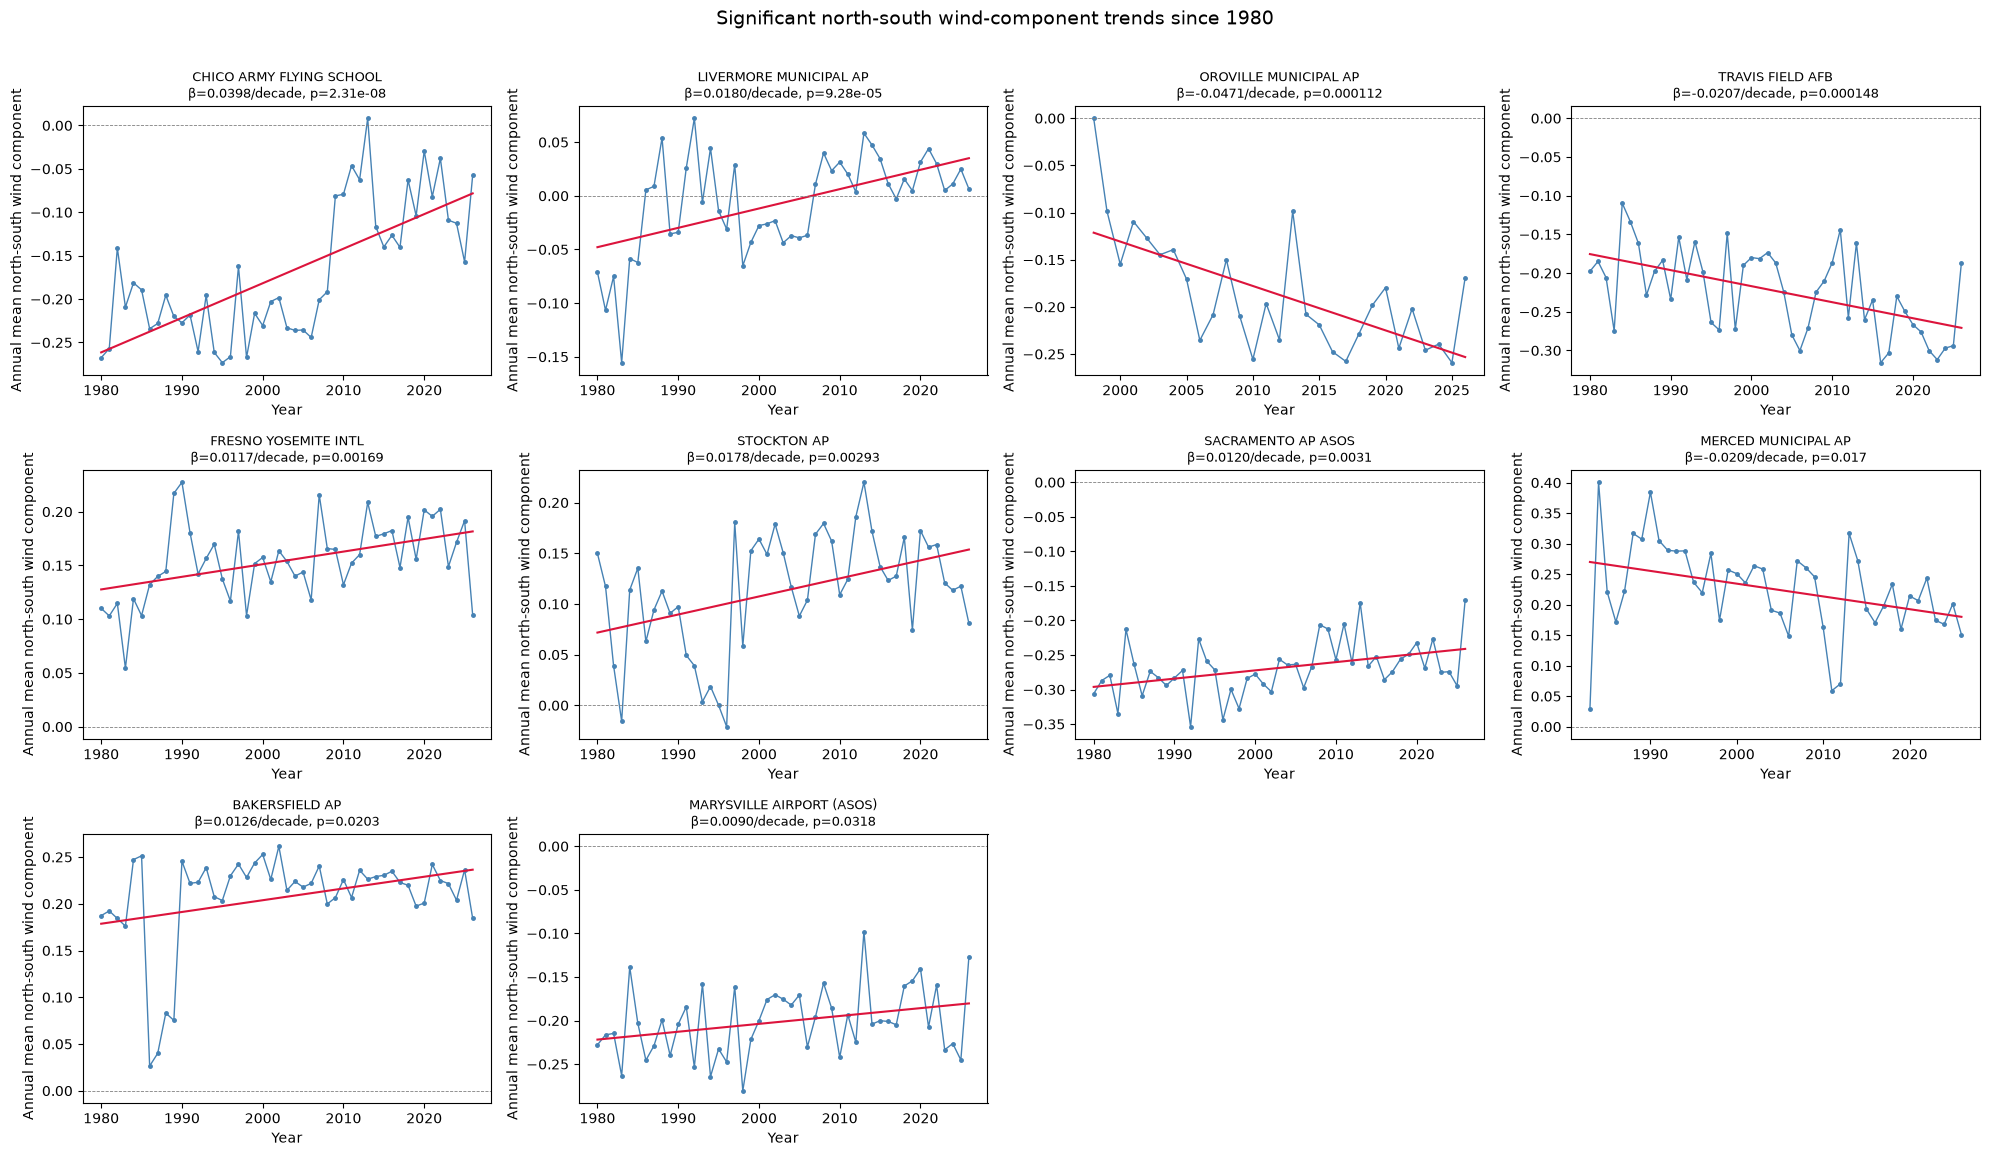

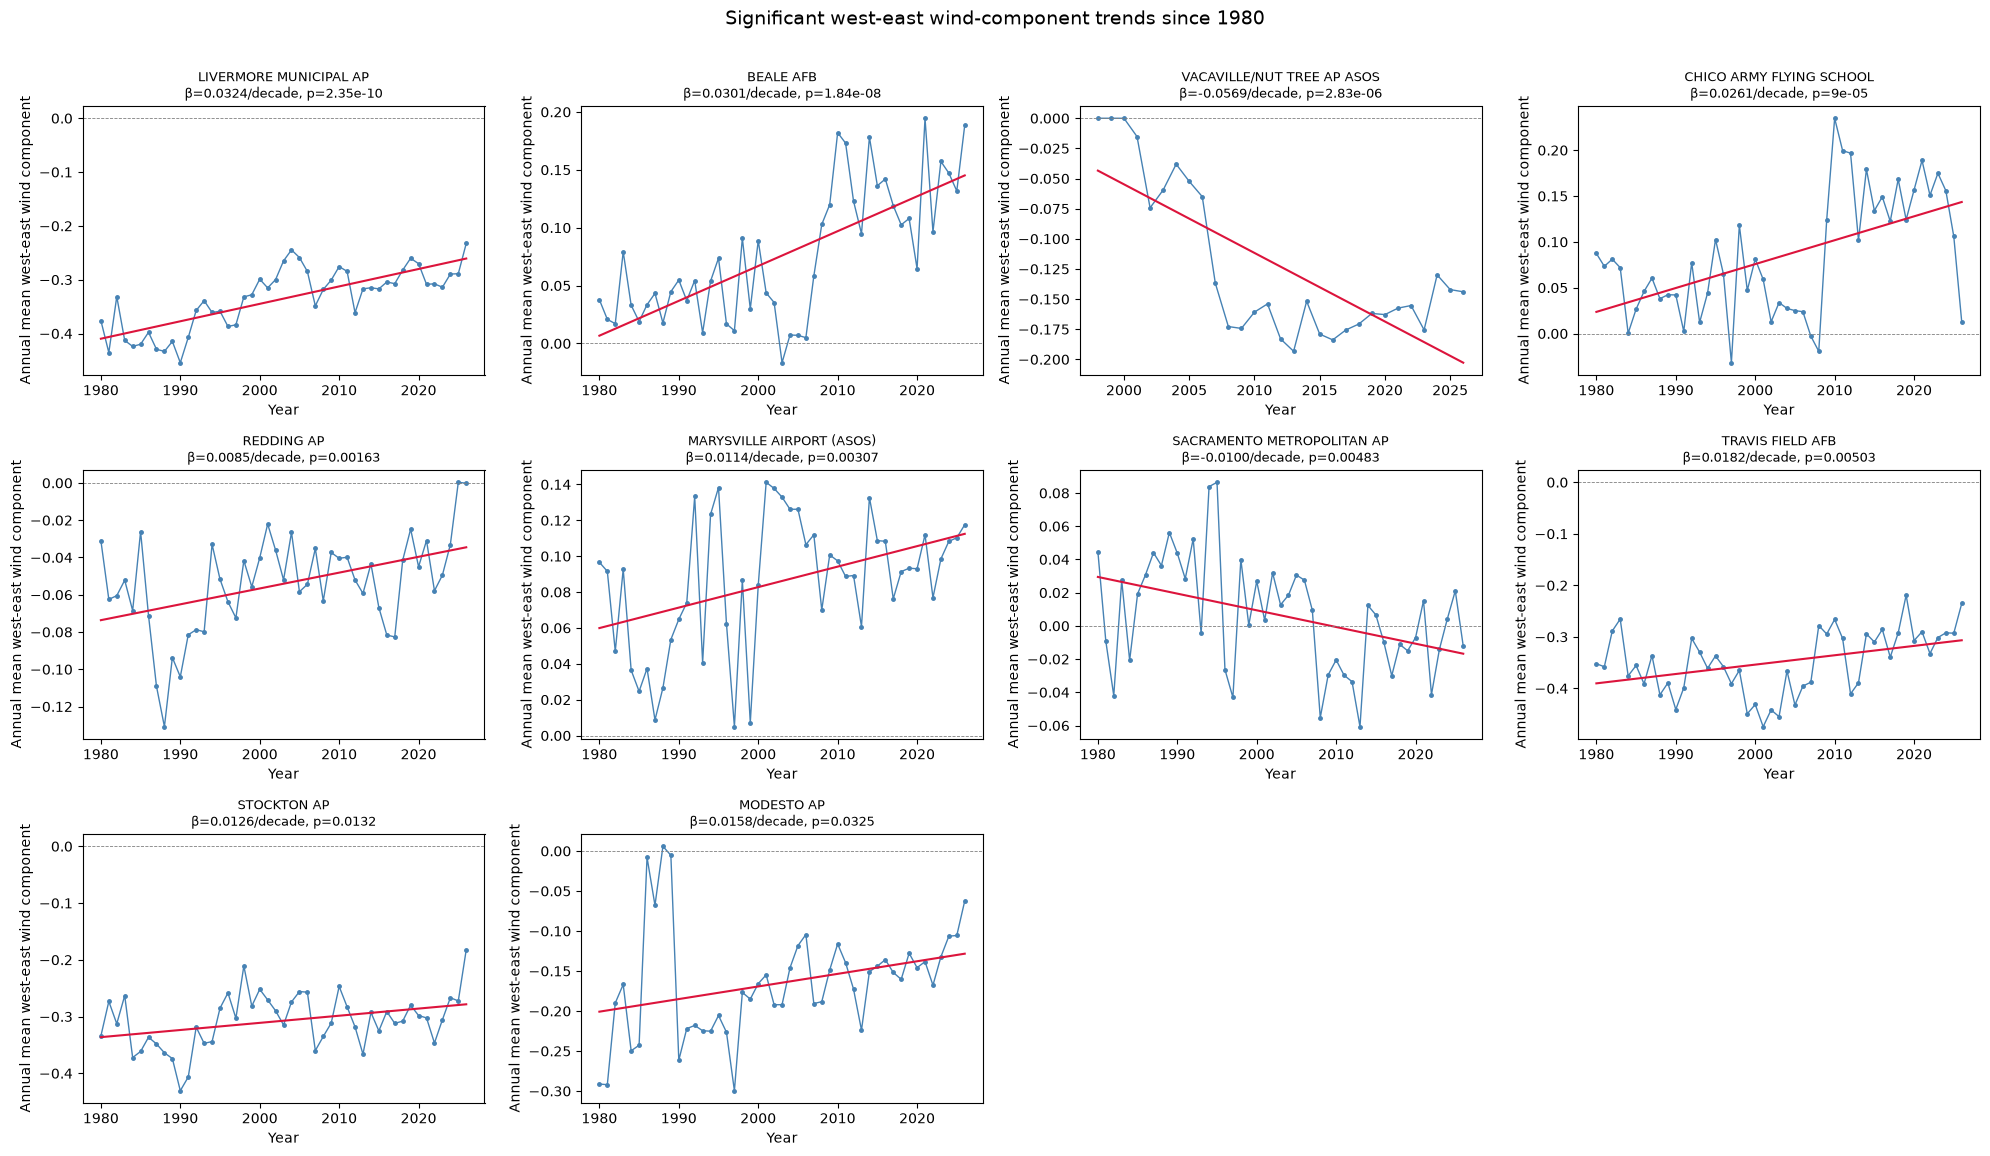

In [15]:
# Trend analysis of annual mean wind components since 1980

# 1) Build annual station means
wind_since_1980 = CV_rows[CV_rows["year"] >= 1980].copy()

# compute annual mean wind components and number of observations per station
annual_wind = (
    wind_since_1980
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        ns_mean=("wind_ns_component", "mean"),
        we_mean=("wind_we_component", "mean"),
        n_obs=("wind_ns_component", "size"),
    )
)

# 2) Fit linear trends by station for each component
min_years = 10
trend_rows = []

# loop through each station and component to fit linear regression and store results
for station, g in annual_wind.groupby("STATION"):
    for col, comp_name in [("ns_mean", "north_south"), ("we_mean", "west_east")]:
        d = g[["year", col]].dropna()
        if d["year"].nunique() < min_years:
            continue

        x = d["year"].to_numpy()
        y = d[col].to_numpy()
        fit = stats.linregress(x, y)

        trend_rows.append({
            "STATION": station,
            "component": comp_name,
            "n_years": int(d["year"].nunique()),
            "slope_per_year": fit.slope,
            "slope_per_decade": fit.slope * 10,
            "intercept": fit.intercept,
            "r_value": fit.rvalue,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
            "std_err": fit.stderr,
        })

# create a DataFrame from the trend results and filter for significant trends (p < 0.05)
trend_df = pd.DataFrame(trend_rows)
sig_trends = trend_df[trend_df["p_value"] < 0.05].copy()

print(f"Total station-component trends tested: {len(trend_df)}")
print(f"Significant trends (p < 0.05): {len(sig_trends)}")
print(sig_trends.sort_values(["component", "p_value"]).head(20))

# 3) Plot significant trends for each component
for comp_name, col, ylab in [
    ("north_south", "ns_mean", "Annual mean north-south wind component"),
    ("west_east", "we_mean", "Annual mean west-east wind component"),
]:
    sig_comp = sig_trends[sig_trends["component"] == comp_name].sort_values("p_value")
    stations = sig_comp["STATION"].tolist()

    if len(stations) == 0:
        print(f"No significant {comp_name} trends found.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(stations) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.8 * nrows), sharex=False, sharey=False)
    axes = np.array(axes).reshape(-1)

# Loop through each station and plot the annual mean wind component and the fitted trend line
    for i, station in enumerate(stations):
        ax = axes[i]
        d = annual_wind[annual_wind["STATION"] == station][["year", col]].dropna().sort_values("year")
        t = sig_comp[sig_comp["STATION"] == station].iloc[0]

        ax.plot(d["year"], d[col], marker="o", linewidth=1, markersize=2.5, color="steelblue")
        ax.plot(
            d["year"],
            t["intercept"] + t["slope_per_year"] * d["year"],
            color="crimson",
            linewidth=1.5
        )
        ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
        ax.set_title(
            f"{station}\nβ={t['slope_per_decade']:.4f}/decade, p={t['p_value']:.3g}",
            fontsize=9
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(ylab)

    for j in range(len(stations), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Significant {comp_name.replace('_', '-') } wind-component trends since 1980", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

In [16]:
# Classify each observation as up-valley or down-valley relative to valley angle = 330°
valley_angle = 330.0  # interpreted as the up-valley flow direction (toward 330°)

wd = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")  # meteorological "from" direction
ws = pd.to_numeric(CV_rows["HourlyWindSpeed"], errors="coerce")

# Convert to "to" direction (direction wind is blowing toward)
wd_to = (wd + 180.0) % 360.0

# Signed alignment with valley axis (+ up-valley, - down-valley)
# cos(delta) > 0 means aligned with up-valley axis, < 0 means opposite (down-valley)
delta = np.deg2rad(wd_to - valley_angle)
valley_alignment = np.cos(delta)

# Optional speed-weighted along-valley component
CV_rows["valley_along_component"] = valley_alignment * ws

calm_mask = wd.eq(0) | ws.eq(0)  # "000" direction and/or zero speed => calm
missing_mask = wd.isna() | ws.isna()

# Classify each observation as "up_valley", "down_valley", "cross_valley", "calm", or "missing"
CV_rows["valley_wind_type"] = np.select(
    [
        missing_mask,
        calm_mask,
        valley_alignment > 0,
        valley_alignment < 0,
    ],
    [
        "missing",
        "calm",
        "up_valley",
        "down_valley",
    ],
    default="cross_valley",
)

# Quick station-level check of the counts of each valley wind type
station_valley_counts = (
    CV_rows.groupby(["STATION", "valley_wind_type"])
    .size()
    .unstack(fill_value=0)
)

station_valley_counts.head()

valley_wind_type,calm,down_valley,up_valley
STATION,,,
BAKERSFIELD AP,183307,469916,239586
BEALE AFB,143664,183028,363168
CASTLE AFB,196064,385731,113260
CHICO ARMY FLYING SCHOOL,131538,127932,211257
FRESNO,2540,43685,14156


Total station-category trends tested: 48
Significant trends (p < 0.05): 18
                       STATION    wind_type  n_years  slope_per_year_pct  \
45  VACAVILLE/NUT TREE AP ASOS  down_valley       26            0.566903   
3                    BEALE AFB  down_valley       47           -0.159112   
1               BAKERSFIELD AP  down_valley       47            0.128434   
47        VISALIA MUNICIPAL AP  down_valley       47           -0.294199   
11        FRESNO YOSEMITE INTL  down_valley       47            0.157450   
17      LIVERMORE MUNICIPAL AP  down_valley       47           -0.138192   
43            TRAVIS FIELD AFB  down_valley       47           -0.356189   
21   MARYSVILLE AIRPORT (ASOS)  down_valley       47           -0.095252   
23         MERCED MUNICIPAL AP  down_valley       44           -0.167868   
44  VACAVILLE/NUT TREE AP ASOS    up_valley       26           -0.566903   
2                    BEALE AFB    up_valley       47            0.159112   
0            

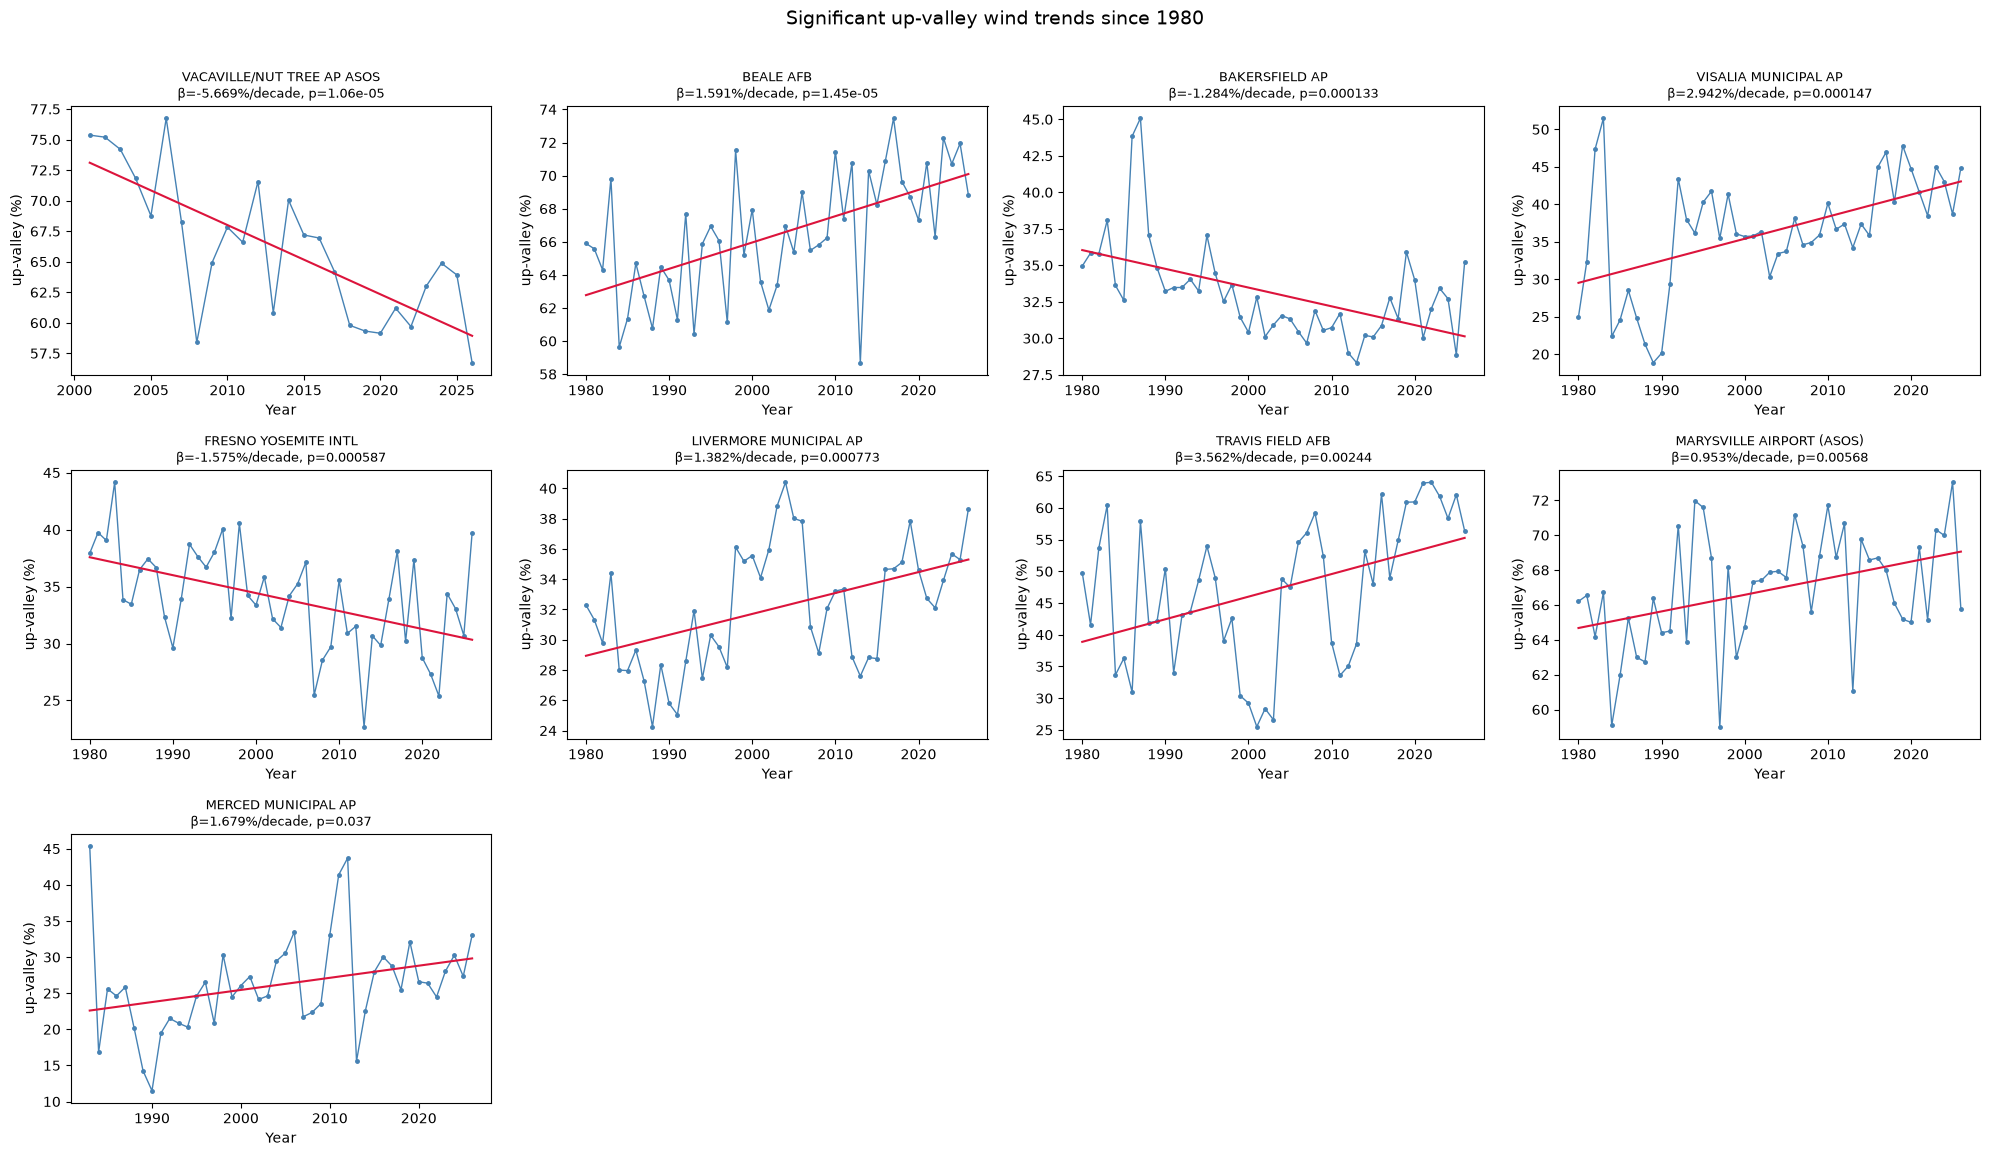

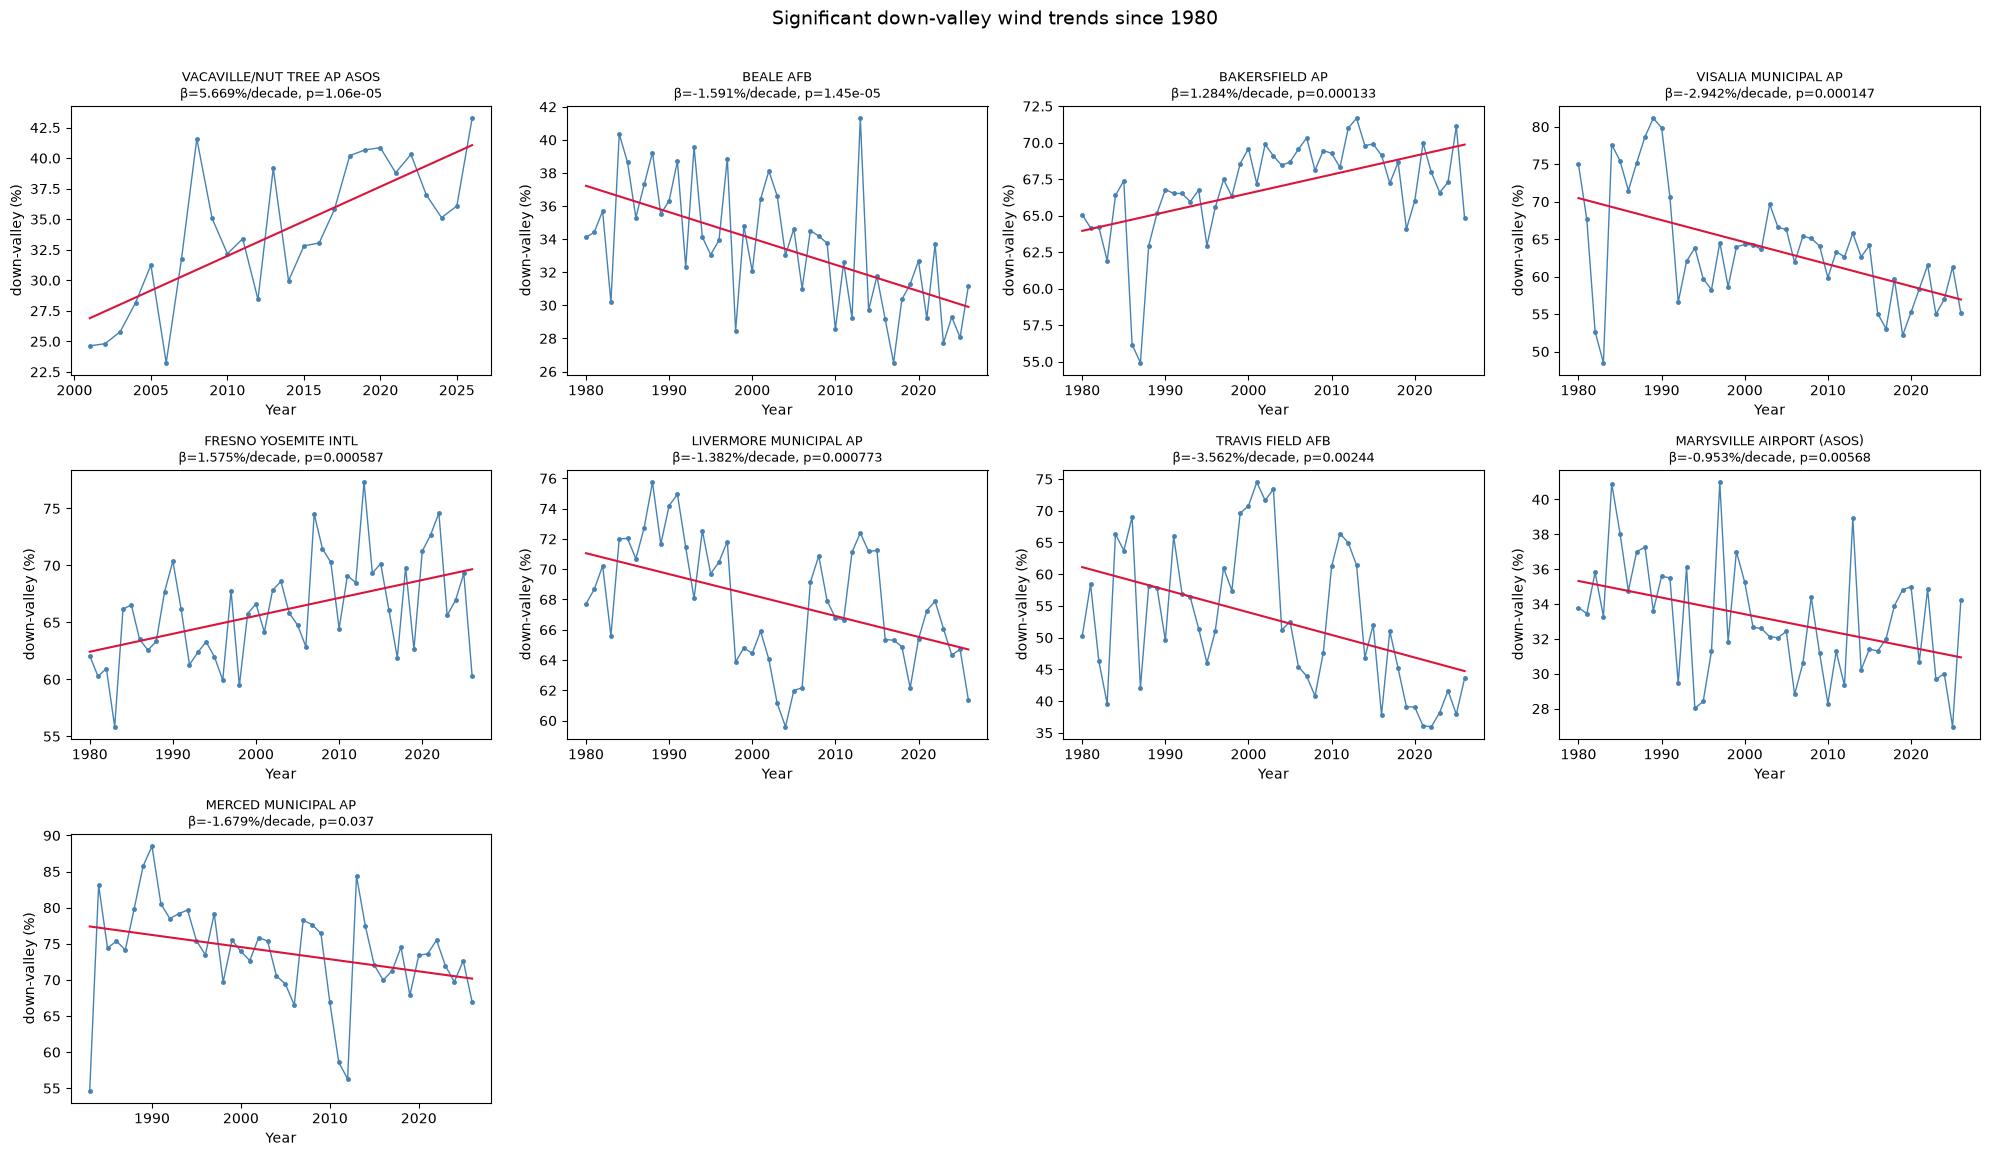

In [17]:
# Trend analysis of annual up-valley and down-valley wind frequency since 1980

valley_since_1980 = CV_rows[CV_rows["year"] >= 1980].copy()

# keep only observations with a classified valley wind type
valley_since_1980 = valley_since_1980[valley_since_1980["valley_wind_type"].isin(["up_valley", "down_valley"])]

# compute annual counts of up-valley and down-valley observations per station
annual_valley = (
    valley_since_1980
    .groupby(["STATION", "year", "valley_wind_type"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

# convert counts to yearly percentages within each station
annual_valley["total"] = annual_valley.groupby(["STATION", "year"])["count"].transform("sum")
annual_valley["pct"] = 100 * annual_valley["count"] / annual_valley["total"]

# Fit linear trends by station for each valley wind type
trend_rows = []
min_years = 10

# loop through each station and valley wind type to fit linear regression and store results
for station, g in annual_valley.groupby("STATION"):
    for wind_type in ["up_valley", "down_valley"]:
        d = g[g["valley_wind_type"] == wind_type][["year", "pct"]].dropna()
        if d["year"].nunique() < min_years:
            continue

        x = d["year"].to_numpy()
        y = d["pct"].to_numpy()
        fit = stats.linregress(x, y)

        trend_rows.append({
            "STATION": station,
            "wind_type": wind_type,
            "n_years": int(d["year"].nunique()),
            "slope_per_year_pct": fit.slope,
            "slope_per_decade_pct": fit.slope * 10,
            "intercept": fit.intercept,
            "r_value": fit.rvalue,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
            "std_err": fit.stderr,
        })

# create a DataFrame from the trend results and filter for significant trends (p < 0.05)
valley_trend_df = pd.DataFrame(trend_rows)
valley_sig_trends = valley_trend_df[valley_trend_df["p_value"] < 0.05].copy()

# print the number of total trends tested and significant trends found
# and display the top 20 significant trends sorted by wind type and p-value
print(f"Total station-category trends tested: {len(valley_trend_df)}")
print(f"Significant trends (p < 0.05): {len(valley_sig_trends)}")
print(valley_sig_trends.sort_values(["wind_type", "p_value"]).head(20))

# Plot significant trends
for wind_type in ["up_valley", "down_valley"]:
    sig_comp = valley_sig_trends[valley_sig_trends["wind_type"] == wind_type].sort_values("p_value")
    stations = sig_comp["STATION"].tolist()

    if len(stations) == 0:
        print(f"No significant {wind_type} trends found.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(stations) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.8 * nrows), sharex=False, sharey=False)
    axes = np.array(axes).reshape(-1)

# Loop through each station and plot the annual percentage of valley wind type and the fitted trend line
    for i, station in enumerate(stations):
        ax = axes[i]
        d = annual_valley[
            (annual_valley["STATION"] == station) &
            (annual_valley["valley_wind_type"] == wind_type)
        ][["year", "pct"]].dropna().sort_values("year")

        t = sig_comp[sig_comp["STATION"] == station].iloc[0]

        ax.plot(d["year"], d["pct"], marker="o", linewidth=1, markersize=2.5, color="steelblue")
        ax.plot(
            d["year"],
            t["intercept"] + t["slope_per_year_pct"] * d["year"],
            color="crimson",
            linewidth=1.5
        )
        ax.set_title(
            f"{station}\nβ={t['slope_per_decade_pct']:.3f}%/decade, p={t['p_value']:.3g}",
            fontsize=9
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(f"{wind_type.replace('_', '-')} (%)")

    for j in range(len(stations), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Significant {wind_type.replace('_', '-')} wind trends since 1980", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

In [18]:
# Up-/down-valley trend analysis for fog events only (HourlyVisibility < 1.0) since 1980

# Start from low-visibility event table built earlier
fog_ev = low_vis_events.copy()

# # Ensure datetime
# if not pd.api.types.is_datetime64_any_dtype(fog_ev["DATE"]):
#     fog_ev["DATE"] = pd.to_datetime(fog_ev["DATE"], errors="coerce")

# Recompute valley alignment on fog-event observations
wd_fog = pd.to_numeric(fog_ev["HourlyWindDirection"], errors="coerce")
ws_fog = pd.to_numeric(fog_ev["HourlyWindSpeed"], errors="coerce")
# wd_to_fog is the wind direction plus 180 degrees, representing the direction the wind is blowing toward
# wrapped to 360 degrees meaning that 0° and 360° are equivalent
wd_to_fog = (wd_fog + 180.0) % 360.0
alignment_fog = np.cos(np.deg2rad(wd_to_fog - valley_angle))

# Classify each fog-event observation as "up_valley", "down_valley", "cross_valley", "calm", or "missing"
fog_ev["obs_valley_type"] = np.select(
    [
        wd_fog.isna() | ws_fog.isna(),
        wd_fog.eq(0) | ws_fog.eq(0),
        alignment_fog > 0,
        alignment_fog < 0,
    ],
    ["missing", "calm", "up_valley", "down_valley"],
    default="cross_valley",
)

# Keep years since 1980
fog_ev = fog_ev[fog_ev["year"] >= 1980].copy()

# Classify each event by dominant valley direction (up vs down)
event_type = (
    fog_ev[fog_ev["obs_valley_type"].isin(["up_valley", "down_valley"])]
    .groupby(["STATION", "event_id", "year", "obs_valley_type"], as_index=False)
    .size()
    .pivot_table(
        index=["STATION", "event_id", "year"],
        columns="obs_valley_type",
        values="size",
        fill_value=0
    )
    .reset_index()
)

# Ensure that both "up_valley" and "down_valley" columns exist in the event_type DataFrame
for c in ["up_valley", "down_valley"]:
    if c not in event_type.columns:
        event_type[c] = 0

# Classify each event as "up_valley", "down_valley", or "tie" based on the counts of up-valley and down-valley observations
event_type["event_wind_type"] = np.select(
    [event_type["up_valley"] > event_type["down_valley"],
     event_type["down_valley"] > event_type["up_valley"]],
    ["up_valley", "down_valley"],
    default="tie"
)

event_type = event_type[event_type["event_wind_type"].isin(["up_valley", "down_valley"])].copy()

# Annual event counts and percentages by station
annual_fog_event_valley = (
    event_type
    .groupby(["STATION", "year", "event_wind_type"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

# compute total events per station-year
annual_fog_event_valley["total"] = annual_fog_event_valley.groupby(["STATION", "year"])["count"].transform("sum")
# computer percentage of each wind type per station-year
annual_fog_event_valley["pct"] = 100 * annual_fog_event_valley["count"] / annual_fog_event_valley["total"]

# Trend fitting
fog_event_trend_rows = []
min_years = 10

# loop through each station and wind type to fit linear regression and store results
for station, g in annual_fog_event_valley.groupby("STATION"):
    for wind_type in ["up_valley", "down_valley"]:
        d = g[g["event_wind_type"] == wind_type][["year", "pct"]].dropna()
        if d["year"].nunique() < min_years:
            continue

        fit = stats.linregress(d["year"].to_numpy(), d["pct"].to_numpy())
        fog_event_trend_rows.append({
            "STATION": station,
            "wind_type": wind_type,
            "n_years": int(d["year"].nunique()),
            "slope_per_year_pct": fit.slope,
            "slope_per_decade_pct": fit.slope * 10,
            "intercept": fit.intercept,
            "r_value": fit.rvalue,
            "r_squared": fit.rvalue**2,
            "p_value": fit.pvalue,
            "std_err": fit.stderr,
        })

# create a DataFrame from the trend results and filter for significant trends (p < 0.05)
fog_event_valley_trend_df = pd.DataFrame(fog_event_trend_rows)
fog_event_valley_sig_trends = fog_event_valley_trend_df[fog_event_valley_trend_df["p_value"] < 0.05].copy()

# print the number of total trends tested and significant trends found
print(f"Total fog-event station-category trends tested: {len(fog_event_valley_trend_df)}")
print(f"Significant fog-event trends (p < 0.05): {len(fog_event_valley_sig_trends)}")
print(fog_event_valley_sig_trends.sort_values(["wind_type", "p_value"]).head(20))

Total fog-event station-category trends tested: 46
Significant fog-event trends (p < 0.05): 4
                       STATION    wind_type  n_years  slope_per_year_pct  \
9         FRESNO YOSEMITE INTL  down_valley       41            0.434969   
37  SACRAMENTO METROPOLITAN AP  down_valley       37            0.502240   
8         FRESNO YOSEMITE INTL    up_valley       41           -0.434969   
36  SACRAMENTO METROPOLITAN AP    up_valley       37           -0.502240   

    slope_per_decade_pct    intercept   r_value  r_squared   p_value   std_err  
9               4.349691  -834.625106  0.492418   0.242475  0.001074  0.123109  
37              5.022396  -948.718675  0.514609   0.264822  0.001119  0.141448  
8              -4.349691   934.625106 -0.492418   0.242475  0.001074  0.123109  
36             -5.022396  1048.718675 -0.514609   0.264822  0.001119  0.141448  


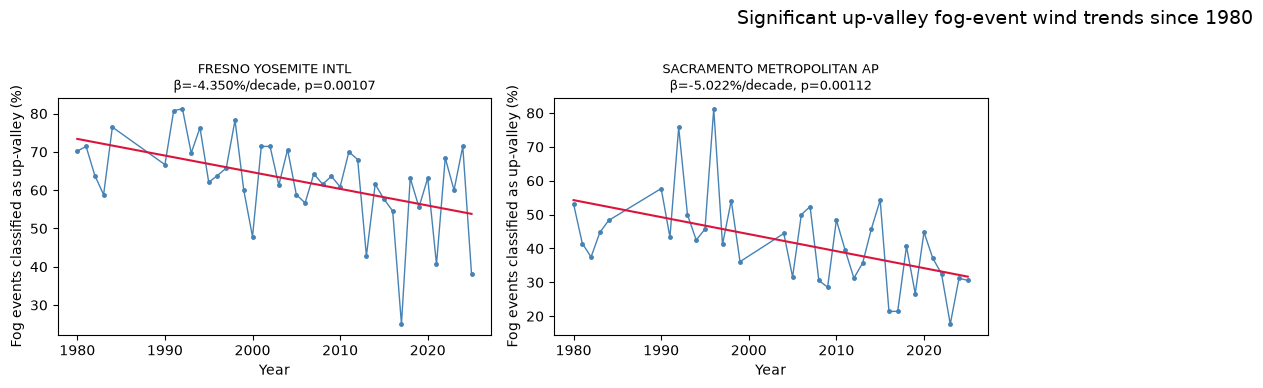

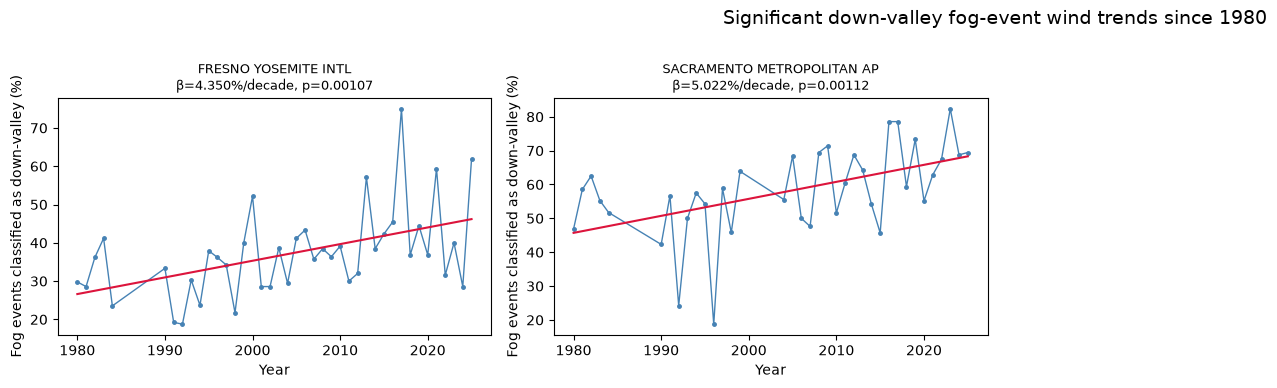

In [19]:
# Plot significant up-/down-valley trends for fog-event station categories

# plot the annual percentage of fog events classified per wind type
# the fitted trend line for each station with a significant trend
for wind_type in ["up_valley", "down_valley"]:
    sig_comp = (
        fog_event_valley_sig_trends[fog_event_valley_sig_trends["wind_type"] == wind_type]
        .sort_values("p_value")
    )
    stations = sig_comp["STATION"].tolist()

# Skip if no significant stations found
    if len(stations) == 0:
        print(f"No significant fog-event {wind_type} trends found.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(stations) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.8 * nrows), sharex=False, sharey=False)
    axes = np.array(axes).reshape(-1)

    for i, station in enumerate(stations):
        ax = axes[i]
        d = annual_fog_event_valley[
            (annual_fog_event_valley["STATION"] == station) &
            (annual_fog_event_valley["event_wind_type"] == wind_type)
        ][["year", "pct"]].dropna().sort_values("year")

        t = sig_comp[sig_comp["STATION"] == station].iloc[0]

        ax.plot(d["year"], d["pct"], marker="o", linewidth=1, markersize=2.5, color="steelblue")
        ax.plot(
            d["year"],
            t["intercept"] + t["slope_per_year_pct"] * d["year"],
            color="crimson",
            linewidth=1.5
        )
        ax.set_title(
            f"{station}\nβ={t['slope_per_decade_pct']:.3f}%/decade, p={t['p_value']:.3g}",
            fontsize=9
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(f"Fog events classified as {wind_type.replace('_', '-')} (%)")

    for j in range(len(stations), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        f"Significant {wind_type.replace('_', '-')} fog-event wind trends since 1980",
        fontsize=14,
        y=1.01
    )
    plt.tight_layout()
    plt.show()

Total station-category trends tested: 52
Significant trends (p < 0.05): 18
                        STATION    wind_type  n_years  slope_per_year_pct  \
13         FRESNO YOSEMITE INTL  down_valley       83            0.106240   
51         VISALIA MUNICIPAL AP  down_valley       53           -0.336261   
49   VACAVILLE/NUT TREE AP ASOS  down_valley       26            0.566903   
37           SACRAMENTO AP ASOS  down_valley       96           -0.048058   
23    MARYSVILLE AIRPORT (ASOS)  down_valley       57           -0.184647   
1                BAKERSFIELD AP  down_valley       99            0.042125   
19       LIVERMORE MUNICIPAL AP  down_valley       53           -0.127907   
3                     BEALE AFB  down_valley       67           -0.122919   
25          MERCED MUNICIPAL AP  down_valley       44           -0.167868   
11  FRESNO CHANDLER DOWNTOWN AP  down_valley       31            0.074469   
12         FRESNO YOSEMITE INTL    up_valley       83           -0.106240   
4

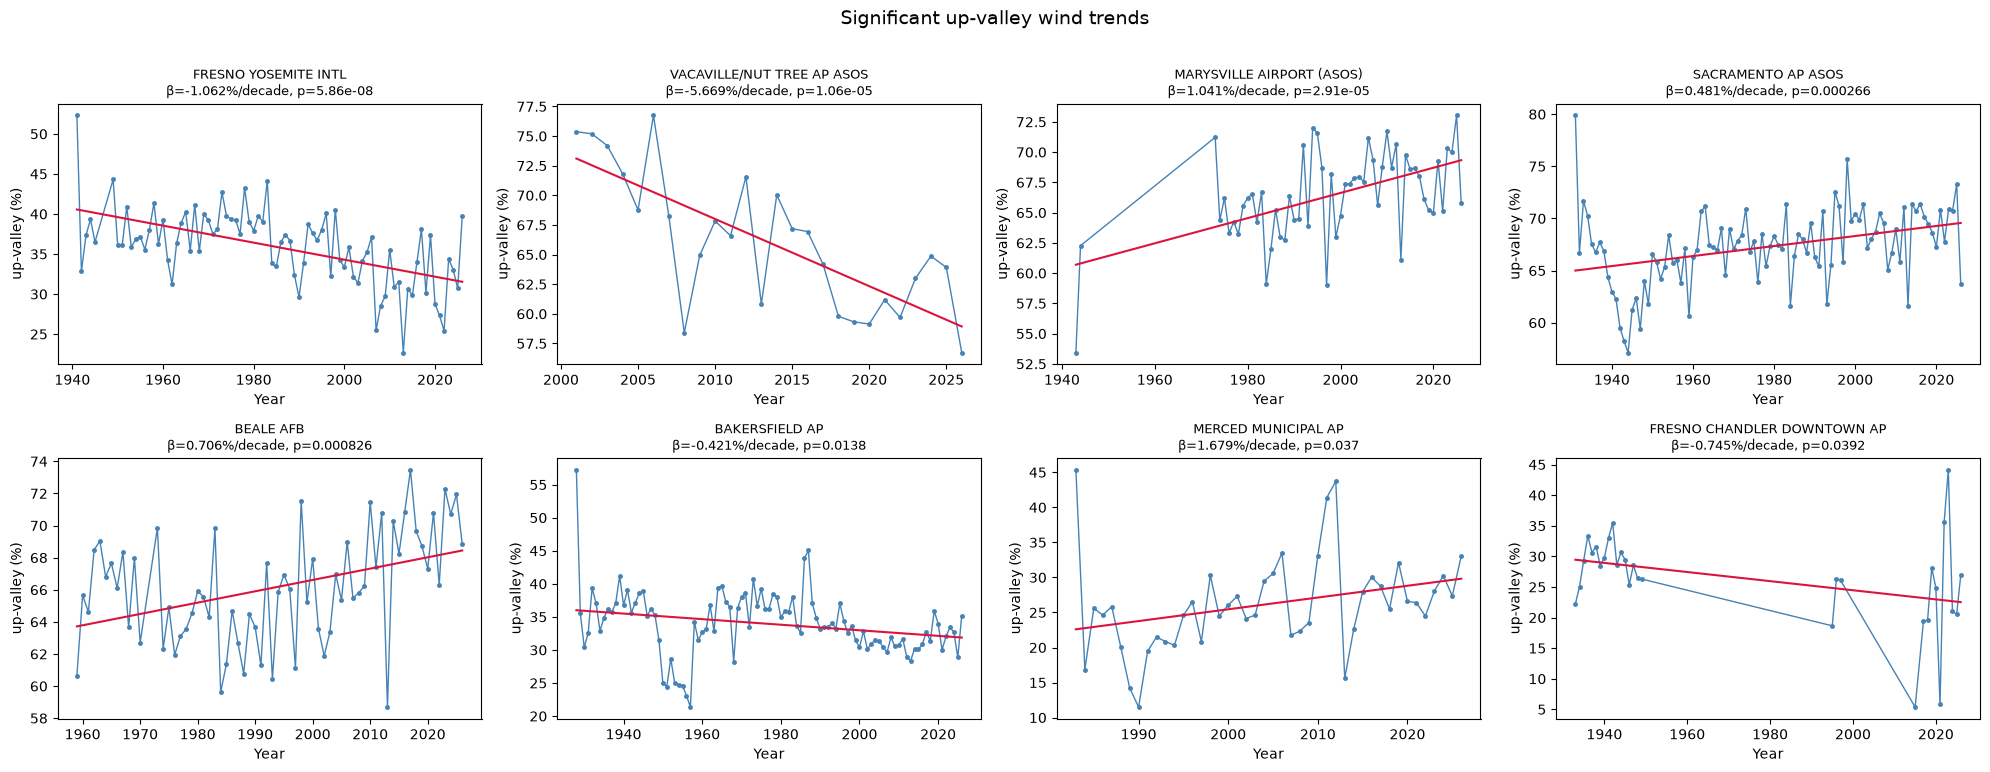

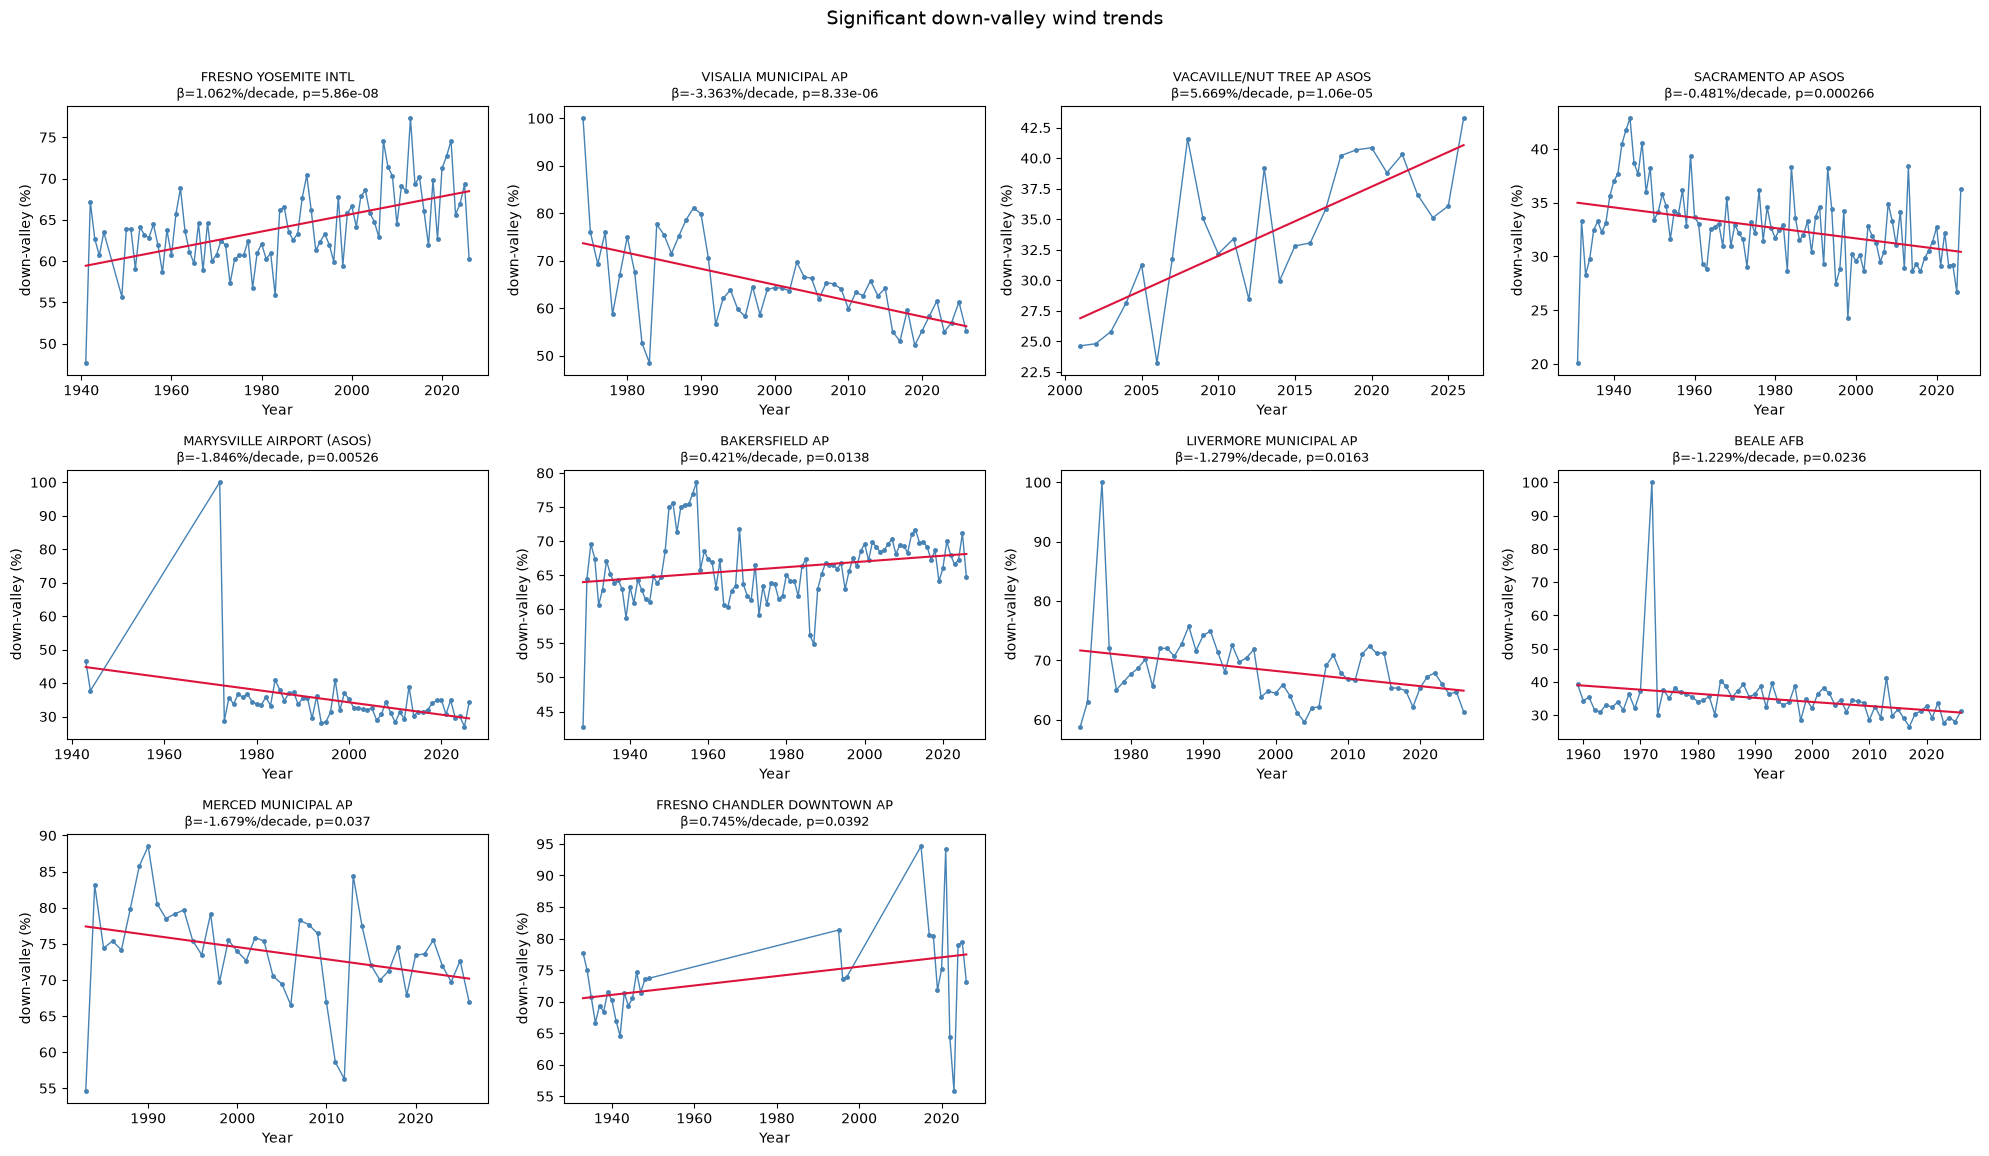

In [20]:
# Trend analysis of annual up-valley and down-valley wind frequency since 1980

# keep only observations with a classified valley wind type
valley_winds = CV_rows[CV_rows["valley_wind_type"].isin(["up_valley", "down_valley"])]

# compute annual counts of up-valley and down-valley observations per station
annual_valley = (
    valley_winds
    .groupby(["STATION", "year", "valley_wind_type"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

# convert counts to yearly percentages within each station
annual_valley["total"] = annual_valley.groupby(["STATION", "year"])["count"].transform("sum")
annual_valley["pct"] = 100 * annual_valley["count"] / annual_valley["total"]

# Fit linear trends by station for each valley wind type
trend_rows = []
min_years = 10

# loop through each station and valley wind type to fit linear regression and store results
for station, g in annual_valley.groupby("STATION"):
    for wind_type in ["up_valley", "down_valley"]:
        d = g[g["valley_wind_type"] == wind_type][["year", "pct"]].dropna()
        if d["year"].nunique() < min_years:
            continue

        x = d["year"].to_numpy()
        y = d["pct"].to_numpy()
        fit = stats.linregress(x, y)

        trend_rows.append({
            "STATION": station,
            "wind_type": wind_type,
            "n_years": int(d["year"].nunique()),
            "slope_per_year_pct": fit.slope,
            "slope_per_decade_pct": fit.slope * 10,
            "intercept": fit.intercept,
            "r_value": fit.rvalue,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
            "std_err": fit.stderr,
        })

# create a DataFrame from the trend results and filter for significant trends (p < 0.05)
valley_trend_df = pd.DataFrame(trend_rows)
valley_sig_trends = valley_trend_df[valley_trend_df["p_value"] < 0.05].copy()

print(f"Total station-category trends tested: {len(valley_trend_df)}")
print(f"Significant trends (p < 0.05): {len(valley_sig_trends)}")
print(valley_sig_trends.sort_values(["wind_type", "p_value"]).head(20))

# Plot significant trends
for wind_type in ["up_valley", "down_valley"]:
    sig_comp = valley_sig_trends[valley_sig_trends["wind_type"] == wind_type].sort_values("p_value")
    stations = sig_comp["STATION"].tolist()

    if len(stations) == 0:
        print(f"No significant {wind_type} trends found.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(stations) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.8 * nrows), sharex=False, sharey=False)
    axes = np.array(axes).reshape(-1)

    for i, station in enumerate(stations):
        ax = axes[i]
        d = annual_valley[
            (annual_valley["STATION"] == station) &
            (annual_valley["valley_wind_type"] == wind_type)
        ][["year", "pct"]].dropna().sort_values("year")

        t = sig_comp[sig_comp["STATION"] == station].iloc[0]

        ax.plot(d["year"], d["pct"], marker="o", linewidth=1, markersize=2.5, color="steelblue")
        ax.plot(
            d["year"],
            t["intercept"] + t["slope_per_year_pct"] * d["year"],
            color="crimson",
            linewidth=1.5
        )
        ax.set_title(
            f"{station}\nβ={t['slope_per_decade_pct']:.3f}%/decade, p={t['p_value']:.3g}",
            fontsize=9
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(f"{wind_type.replace('_', '-')} (%)")

    for j in range(len(stations), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Significant {wind_type.replace('_', '-')} wind trends", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

In [21]:
# Up-/down-valley trend analysis for fog events only (HourlyVisibility < 1.0) since 1980

# Start from low-visibility event table built earlier
fog_ev = low_vis_events.copy()

# Ensure datetime
if not pd.api.types.is_datetime64_any_dtype(fog_ev["DATE"]):
    fog_ev["DATE"] = pd.to_datetime(fog_ev["DATE"], errors="coerce")

# Recompute valley alignment on fog-event observations
wd_fog = pd.to_numeric(fog_ev["HourlyWindDirection"], errors="coerce")
ws_fog = pd.to_numeric(fog_ev["HourlyWindSpeed"], errors="coerce")
wd_to_fog = (wd_fog + 180.0) % 360.0
alignment_fog = np.cos(np.deg2rad(wd_to_fog - valley_angle))

fog_ev["obs_valley_type"] = np.select(
    [
        wd_fog.isna() | ws_fog.isna(),
        wd_fog.eq(0) | ws_fog.eq(0),
        alignment_fog > 0,
        alignment_fog < 0,
    ],
    ["missing", "calm", "up_valley", "down_valley"],
    default="cross_valley",
)

# Classify each event by dominant valley direction (up vs down)
event_type = (
    fog_ev[fog_ev["obs_valley_type"].isin(["up_valley", "down_valley"])]
    .groupby(["STATION", "event_id", "year", "obs_valley_type"], as_index=False)
    .size()
    .pivot_table(
        index=["STATION", "event_id", "year"],
        columns="obs_valley_type",
        values="size",
        fill_value=0
    )
    .reset_index()
)

# Ensure that both "up_valley" and "down_valley" columns exist in the event_type DataFrame
for c in ["up_valley", "down_valley"]:
    if c not in event_type.columns:
        event_type[c] = 0

# Classify each event as "up_valley", "down_valley", or "tie" based on the counts of up-valley and down-valley observations
event_type["event_wind_type"] = np.select(
    [event_type["up_valley"] > event_type["down_valley"],
     event_type["down_valley"] > event_type["up_valley"]],
    ["up_valley", "down_valley"],
    default="tie"
)

event_type = event_type[event_type["event_wind_type"].isin(["up_valley", "down_valley"])].copy()

# Annual event counts and percentages by station
annual_fog_event_valley = (
    event_type
    .groupby(["STATION", "year", "event_wind_type"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

# compute total events per station-year
annual_fog_event_valley["total"] = annual_fog_event_valley.groupby(["STATION", "year"])["count"].transform("sum")
annual_fog_event_valley["pct"] = 100 * annual_fog_event_valley["count"] / annual_fog_event_valley["total"]

# Trend fitting
fog_event_trend_rows = []
min_years = 10

for station, g in annual_fog_event_valley.groupby("STATION"):
    for wind_type in ["up_valley", "down_valley"]:
        d = g[g["event_wind_type"] == wind_type][["year", "pct"]].dropna()
        if d["year"].nunique() < min_years:
            continue

        fit = stats.linregress(d["year"].to_numpy(), d["pct"].to_numpy())
        fog_event_trend_rows.append({
            "STATION": station,
            "wind_type": wind_type,
            "n_years": int(d["year"].nunique()),
            "slope_per_year_pct": fit.slope,
            "slope_per_decade_pct": fit.slope * 10,
            "intercept": fit.intercept,
            "r_value": fit.rvalue,
            "r_squared": fit.rvalue**2,
            "p_value": fit.pvalue,
            "std_err": fit.stderr,
        })

# create a DataFrame from the trend results and filter for significant trends (p < 0.05)
fog_event_valley_trend_df = pd.DataFrame(fog_event_trend_rows)
fog_event_valley_sig_trends = fog_event_valley_trend_df[fog_event_valley_trend_df["p_value"] < 0.05].copy()

# print the number of total trends tested and significant trends found
print(f"Total fog-event station-category trends tested: {len(fog_event_valley_trend_df)}")
print(f"Significant fog-event trends (p < 0.05): {len(fog_event_valley_sig_trends)}")
print(fog_event_valley_sig_trends.sort_values(["wind_type", "p_value"]))

Total fog-event station-category trends tested: 46
Significant fog-event trends (p < 0.05): 10
                       STATION    wind_type  n_years  slope_per_year_pct  \
1               BAKERSFIELD AP  down_valley       82            0.234248   
35    SACRAMENTO MCCLELLAN AFB  down_valley       58            0.200119   
27           RED BLUFF MUNI AP  down_valley       67            0.270363   
37  SACRAMENTO METROPOLITAN AP  down_valley       39            0.399832   
33       SACRAMENTO MATHER AFB  down_valley       56           -0.106601   
34    SACRAMENTO MCCLELLAN AFB    up_valley       58           -0.200119   
0               BAKERSFIELD AP    up_valley       83           -0.199704   
36  SACRAMENTO METROPOLITAN AP    up_valley       39           -0.399832   
26           RED BLUFF MUNI AP    up_valley       65           -0.204058   
32       SACRAMENTO MATHER AFB    up_valley       56            0.106601   

    slope_per_decade_pct   intercept   r_value  r_squared   p_value 

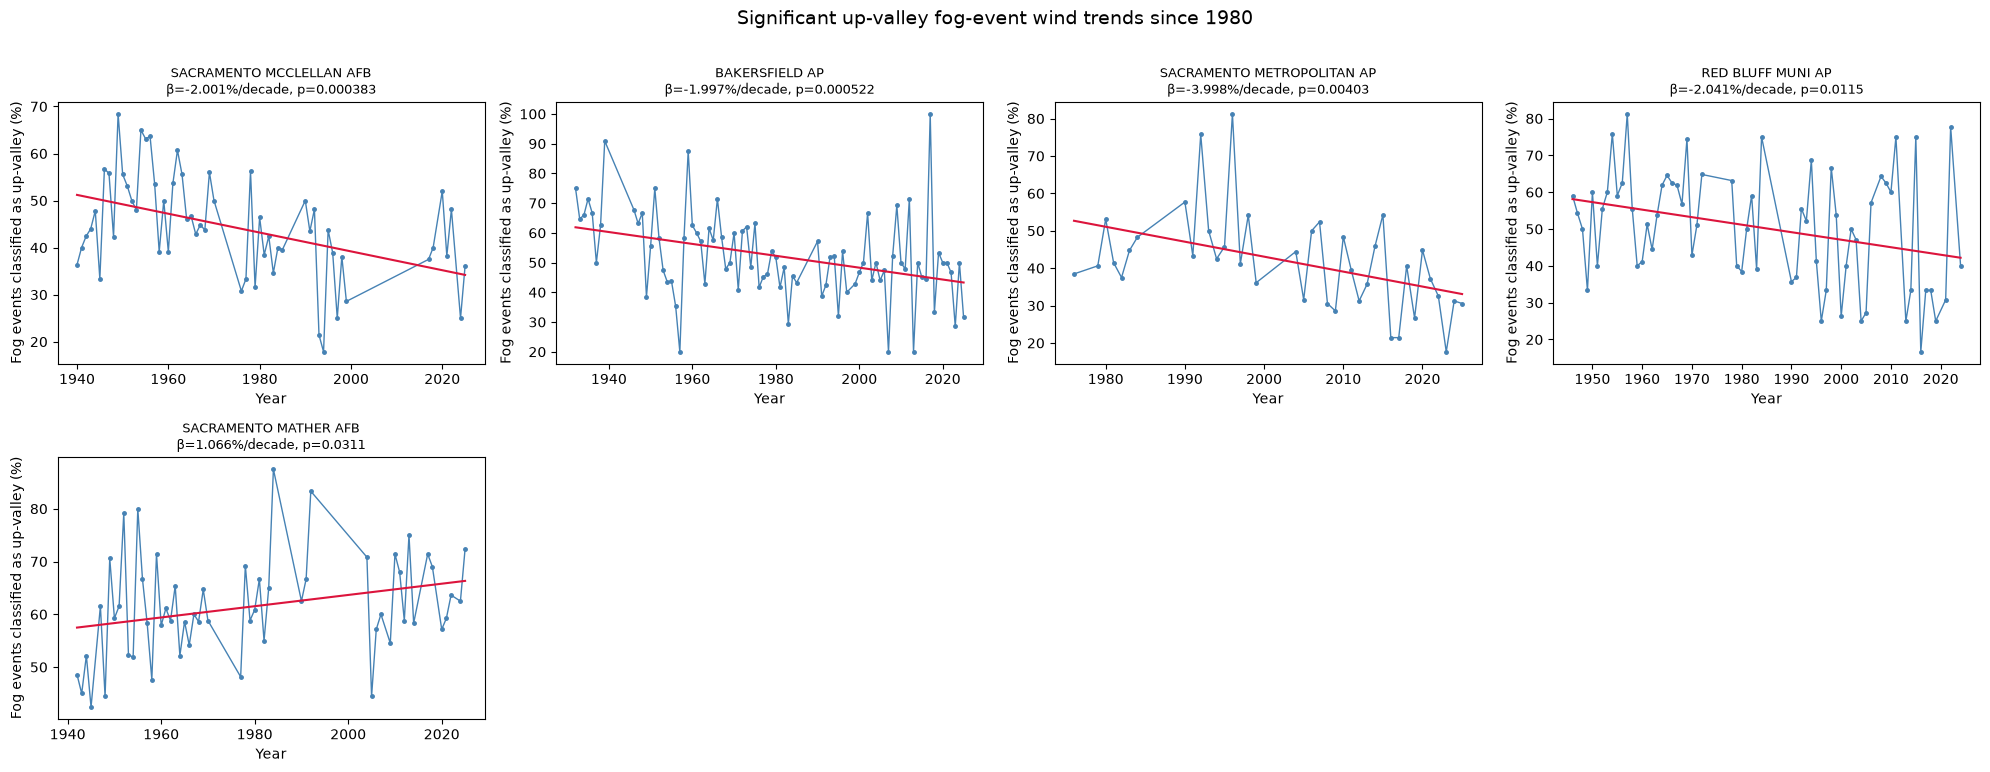

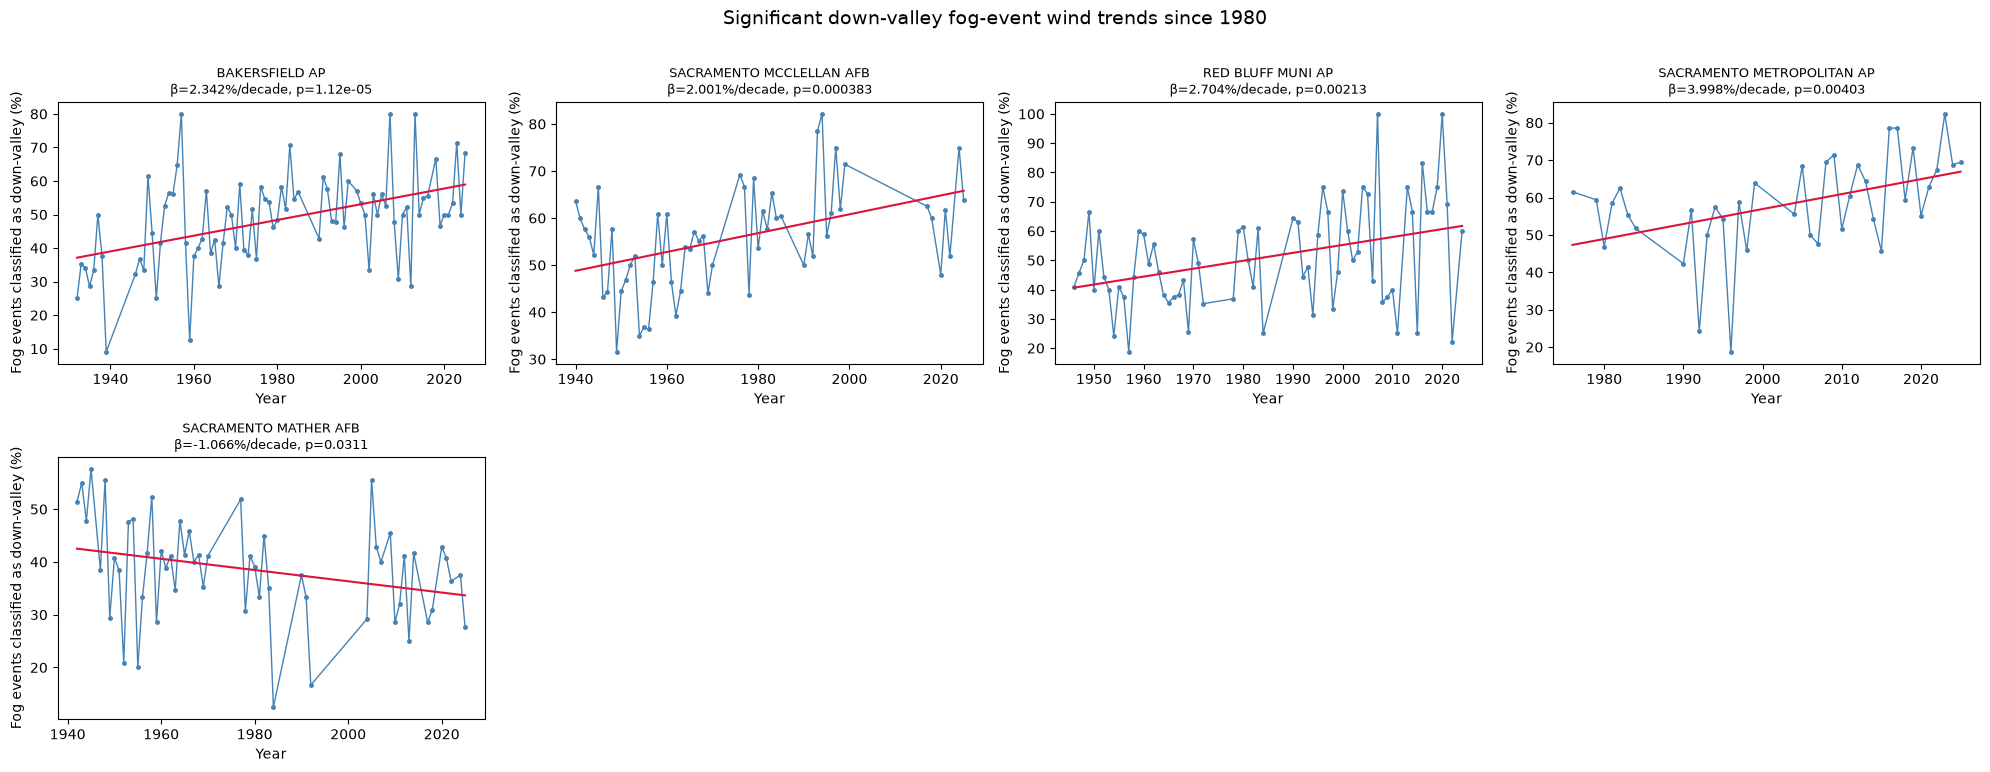

In [22]:
# Plot significant up-/down-valley trends for fog-event station categories

# plot the annual percentage of fog events classified per wind type
# the fitted trend line for each station with a significant trend
for wind_type in ["up_valley", "down_valley"]:
    sig_comp = (
        fog_event_valley_sig_trends[fog_event_valley_sig_trends["wind_type"] == wind_type]
        .sort_values("p_value")
    )
    stations = sig_comp["STATION"].tolist()
    # Skip if no significant stations found
    if len(stations) == 0:
        print(f"No significant fog-event {wind_type} trends found.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(stations) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.8 * nrows), sharex=False, sharey=False)
    axes = np.array(axes).reshape(-1)
    
# Loop through each station and plot the annual percentage of fog events classified per wind type and the fitted trend line
    for i, station in enumerate(stations):
        ax = axes[i]
        d = annual_fog_event_valley[
            (annual_fog_event_valley["STATION"] == station) &
            (annual_fog_event_valley["event_wind_type"] == wind_type)
        ][["year", "pct"]].dropna().sort_values("year")

        t = sig_comp[sig_comp["STATION"] == station].iloc[0]

        ax.plot(d["year"], d["pct"], marker="o", linewidth=1, markersize=2.5, color="steelblue")
        ax.plot(
            d["year"],
            t["intercept"] + t["slope_per_year_pct"] * d["year"],
            color="crimson",
            linewidth=1.5
        )
        ax.set_title(
            f"{station}\nβ={t['slope_per_decade_pct']:.3f}%/decade, p={t['p_value']:.3g}",
            fontsize=9
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(f"Fog events classified as {wind_type.replace('_', '-')} (%)")

    for j in range(len(stations), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        f"Significant {wind_type.replace('_', '-')} fog-event wind trends since 1980",
        fontsize=14,
        y=1.01
    )
    plt.tight_layout()
    plt.show()

In [23]:
# Find station-year gaps > 10 years for wind, temperature, and visibility data

# Define a dictionary for data checks for wind, temperature, and visibility
data_checks = {
    "wind": CV_rows["HourlyWindSpeed"].notna() | CV_rows["HourlyWindDirection"].notna(),
    "temperature": CV_rows["HourlyDryBulbTemperature"].notna(),
    "visibility": CV_rows["HourlyVisibility"].notna(),
}

# Define a function to find station-year gaps greater than a specified minimum gap
def station_year_gaps(mask, label, min_gap=5):
    years_with_data = (
        CV_rows.loc[mask, ["STATION", "year"]]
        .dropna(subset=["STATION", "year"])
        .drop_duplicates()
        .sort_values(["STATION", "year"])
        .copy()
    )
    years_with_data["year"] = years_with_data["year"].astype(int)
# Compute the previous year for each station and the gap between consecutive years
    years_with_data["prev_year"] = years_with_data.groupby("STATION")["year"].shift(1)
    years_with_data["year_jump"] = years_with_data["year"] - years_with_data["prev_year"]
# Filter for gaps greater than the specified minimum gap
    gaps = years_with_data[years_with_data["year_jump"] > min_gap].copy()
    gaps["gap_start_year"] = gaps["prev_year"].astype(int) + 1
    gaps["gap_end_year"] = gaps["year"].astype(int) - 1
    gaps["missing_years_count"] = gaps["year_jump"].astype(int) - 1
    gaps["data_type"] = label

    return gaps[
        ["data_type", "STATION", "prev_year", "year", "gap_start_year", "gap_end_year", "missing_years_count"]
    ].rename(columns={"prev_year": "year_before_gap", "year": "year_after_gap"})

# Find gaps greater than 5 years for wind, temperature, and visibility data
wind_gaps = station_year_gaps(data_checks["wind"], "wind", min_gap=5)
temp_gaps = station_year_gaps(data_checks["temperature"], "temperature", min_gap=5)
vis_gaps = station_year_gaps(data_checks["visibility"], "visibility", min_gap=5)
# Combine all gaps into a single DataFrame and sort by data type, station, and year before the gap
all_gaps = pd.concat([wind_gaps, temp_gaps, vis_gaps], ignore_index=True).sort_values(
    ["data_type", "STATION", "year_before_gap"]
)
# Print the number of gaps found for each data type
print("Wind gaps >5 years:", wind_gaps.shape[0])
print("Temperature gaps >5 years:", temp_gaps.shape[0])
print("Visibility gaps >5 years:", vis_gaps.shape[0])

display(all_gaps)

Wind gaps >5 years: 9
Temperature gaps >5 years: 10
Visibility gaps >5 years: 11


,data_type,STATION,year_before_gap,year_after_gap,gap_start_year,gap_end_year,missing_years_count
9,temperature,CASTLE AFB,2001.0,2007,2002,2006,5
10,temperature,CHICO ARMY FLYING SCHOOL,1945.0,1973,1946,1972,27
11,temperature,FRESNO,1933.0,1939,1934,1938,5
12,temperature,FRESNO CHANDLER DOWNTOWN AP,1949.0,1995,1950,1994,45
13,temperature,FRESNO CHANDLER DOWNTOWN AP,1997.0,2015,1998,2014,17
14,temperature,MARYSVILLE AIRPORT (ASOS),1944.0,1972,1945,1971,27
15,temperature,REDDING AP,1944.0,1973,1945,1972,28
16,temperature,SACRAMENTO MATHER AFB,1931.0,1941,1932,1940,9
17,temperature,SACRAMENTO MATHER AFB,1993.0,2001,1994,2000,7
18,temperature,STOCKTON AP,1954.0,1963,1955,1962,8


Station-category trends available: 46
                       STATION    wind_type  n_years  slope_per_year_pct  \
8         FRESNO YOSEMITE INTL  down_valley       41            0.434969   
36  SACRAMENTO METROPOLITAN AP  down_valley       37            0.502240   
12          LEMOORE REEVES NAS  down_valley       28            0.223327   
38                 STOCKTON AP  down_valley       41            0.141835   
16         MADERA MUNICIPAL AP  down_valley       21            0.558791   
42  VACAVILLE/NUT TREE AP ASOS  down_valley       14           -1.641827   
44        VISALIA MUNICIPAL AP  down_valley       15            0.389680   
26           RED BLUFF MUNI AP  down_valley       38            0.320180   
40            TRAVIS FIELD AFB  down_valley       30            0.140133   
30          SACRAMENTO AP ASOS  down_valley       41            0.133180   
28                  REDDING AP  down_valley       42            0.214851   
10        HANFORD MUNICIPAL AP  down_valley       

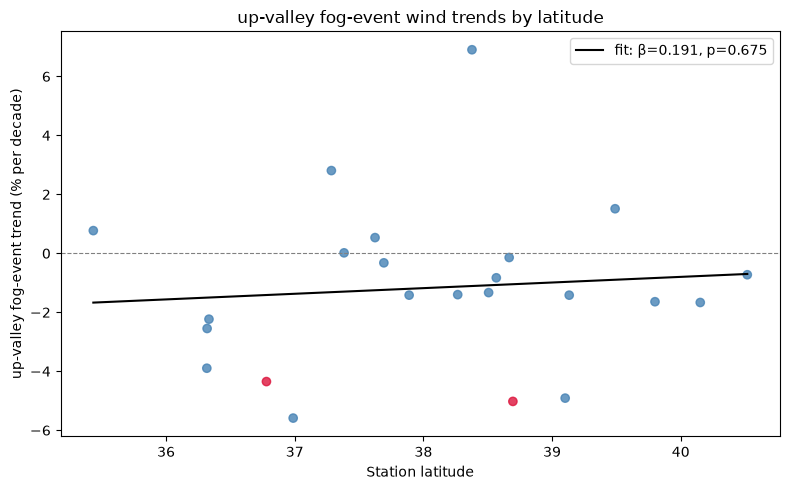

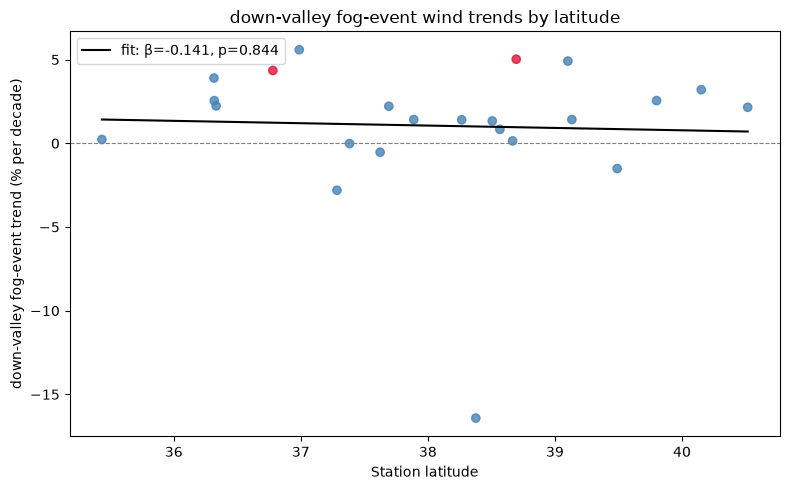

In [24]:
# Trends in up-/down-valley fog-event winds by station latitude

# station latitude lookup
station_lat = (
    CV_rows.groupby("STATION", as_index=False)["LATITUDE"]
    .median()
    .rename(columns={"LATITUDE": "latitude"})
)

# use fog-event annual percentages already computed earlier: annual_fog_event_valley
# columns expected: STATION, year, event_wind_type, pct
min_years = 10
fog_lat_trend_rows = []

#only include years since 1980 for trend analysis   
for (station, wind_type), g in annual_fog_event_valley.groupby(["STATION", "event_wind_type"]):
    g = g[g["year"] >= 1980]
    d = g[["year", "pct"]].dropna()
    if d["year"].nunique() < min_years:
        continue
# Fit linear regression to the annual percentage of fog events classified per wind type for each station
    fit = stats.linregress(d["year"].to_numpy(), d["pct"].to_numpy())
    fog_lat_trend_rows.append(
        {
            "STATION": station,
            "wind_type": wind_type,
            "n_years": int(d["year"].nunique()),
            "slope_per_year_pct": fit.slope,
            "slope_per_decade_pct": fit.slope * 10,
            "p_value": fit.pvalue,
            "r_squared": fit.rvalue**2,
        }
    )

# Merge the trend results with station latitude information and determine significance based on p-value
fog_lat_trends = pd.DataFrame(fog_lat_trend_rows).merge(station_lat, on="STATION", how="left")
fog_lat_trends["significant"] = fog_lat_trends["p_value"] < 0.05

print("Station-category trends available:", fog_lat_trends.shape[0])
print(fog_lat_trends.sort_values(["wind_type", "p_value"]).head(20))

# latitude-gradient test: does trend magnitude vary with latitude?
lat_gradient_rows = []
for wt, g in fog_lat_trends.groupby("wind_type"):
    d = g[["latitude", "slope_per_decade_pct"]].dropna()
    if len(d) < 3:
        continue
    fit = stats.linregress(d["latitude"].to_numpy(), d["slope_per_decade_pct"].to_numpy())
    lat_gradient_rows.append(
        {
            "wind_type": wt,
            "n_stations": len(d),
            "slope_pct_per_decade_per_degree_lat": fit.slope,
            "intercept": fit.intercept,
            "r_squared": fit.rvalue**2,
            "p_value": fit.pvalue,
        }
    )

# Create a DataFrame from the latitude-gradient test results and print it
lat_gradient_df = pd.DataFrame(lat_gradient_rows)
print("\nLatitude-gradient test (trend vs latitude):")
print(lat_gradient_df)

# plot fog event trend magnitude vs station latitude, with linear fit if enough stations
for wt in ["up_valley", "down_valley"]:
    d = fog_lat_trends[fog_lat_trends["wind_type"] == wt].dropna(subset=["latitude", "slope_per_decade_pct"])
    if d.empty:
        print(f"No {wt} fog-event trends to plot.")
        continue

    plt.figure(figsize=(8, 5))
    plt.scatter(
        d["latitude"],
        d["slope_per_decade_pct"],
        c=d["significant"].map({True: "crimson", False: "steelblue"}),
        alpha=0.8
    )

    if len(d) >= 3:
        fit = stats.linregress(d["latitude"].to_numpy(), d["slope_per_decade_pct"].to_numpy())
        xline = np.linspace(d["latitude"].min(), d["latitude"].max(), 100)
        yline = fit.intercept + fit.slope * xline
        plt.plot(xline, yline, color="black", linewidth=1.5,
                 label=f"fit: β={fit.slope:.3f}, p={fit.pvalue:.3g}")

    plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    plt.xlabel("Station latitude")
    plt.ylabel(f"{wt.replace('_', '-')} fog-event trend (% per decade)")
    plt.title(f"{wt.replace('_', '-')} fog-event wind trends by latitude")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()